Title: Combine_future.ipynb

Purpose: Combine all datasets and add the SMARD Data to the dataset

Author: Onno Nennecke on 09.06.2025 Modified: 24.02.2026

Input data: 

- Model output data
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/future_full_year/'

Output data:

- Combined model output: model_output_all.nc
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import scipy.ndimage as ndimage
import seaborn as sns
import os
import glob

In [6]:
#### path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'
# path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/'
path = '/climca/people/onennecke/model_output/not_bias_corrected/future_full_year_one_time/'


files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets.load()

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

### Add SMARD Data

In [8]:
ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))
ts_datasets

combined_ds = ts_datasets.copy()

In [9]:
combined_ds

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

### Save the data

In [10]:
combined_ds['ESM'].values

array(['ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', '

In [11]:
encoding = {}

all_vars = {**combined_ds.data_vars, **combined_ds.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"S{maxlen}"}
encoding

{'gridtype': {'dtype': 'S6'},
 'ESM': {'dtype': 'S13'},
 'run': {'dtype': 'S12'},
 'ESM_run': {'dtype': 'S23'},
 'period': {'dtype': 'S4'}}

In [12]:
encoding = {}

all_vars = {**combined_ds.data_vars, **combined_ds.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'gridtype': {'dtype': 'U6'},
 'ESM': {'dtype': 'U13'},
 'run': {'dtype': 'U12'},
 'ESM_run': {'dtype': 'U23'},
 'period': {'dtype': 'U4'}}

In [13]:
# Save dataset
combined_ds.to_netcdf('/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc', encoding=encoding)
# combined_ds.to_netcdf('/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc')

In [14]:
# Load the saved dataset to verify
ts_datasets = xr.load_dataset('/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc')
ts_datasets

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

In [15]:
ts_datasets['ESM'].values

array(['ACCESS-CM2', 'ACCESS-CM2', 'ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2', 'CESM2',
       'CESM2', '

### Plotting

In [16]:
# Plot timeseries with ts_datasets first year
ts_datasets_one = ts_datasets.isel(ESM_run=0)

# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 91
b = 91 +181
# a = 365
# b = 365 * 2

# Extract time and variables for the chosen range
time = ts_datasets_one['time'][a:b]
demand = ts_datasets_one['demand'][a:b]
wind_off = ts_datasets_one['wind_off_prod'][a:b]
wind_on = ts_datasets_one['wind_on_prod'][a:b]
solar = ts_datasets_one['solar_prod'][a:b]
total_prod = ts_datasets_one['total_prod'][a:b]
Residual_load = ts_datasets_one['Residual_load'][a:b]


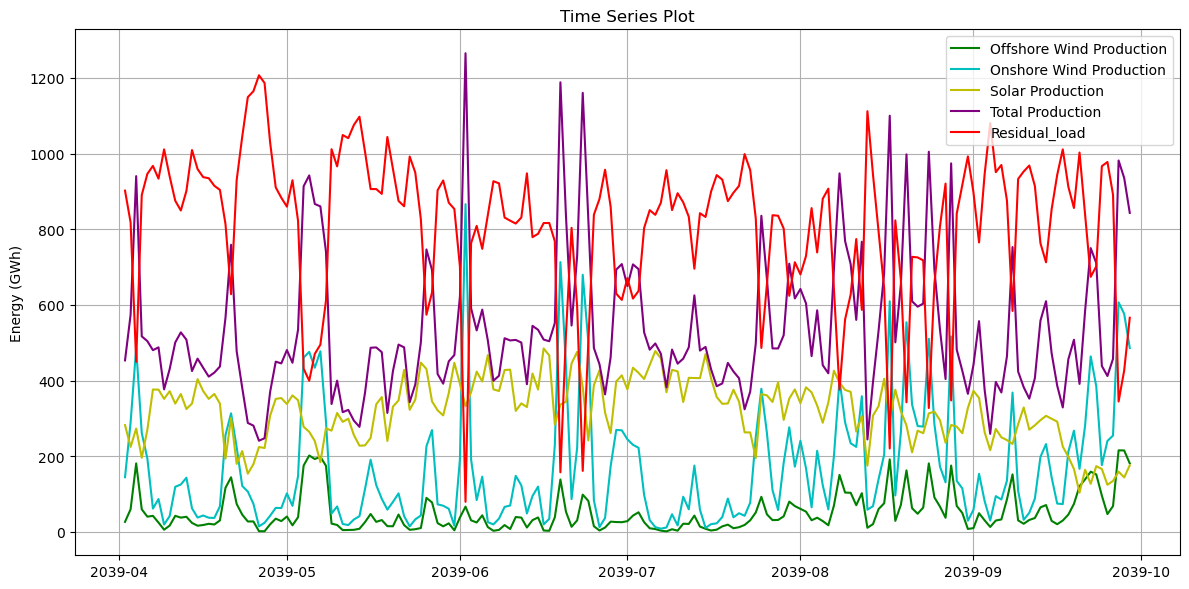

In [17]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
# ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')

ax.plot(time, wind_on, label='Onshore Wind Production', color='c')

ax.plot(time, solar, label='Solar Production', color='y')

ax.plot(time, total_prod, label='Total Production', color='purple')

ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()